## **Theoretical Background**

The simulation of crystalline MgO in this tutorial is based on **Density Functional Theory (DFT)**, which is a quantum mechanical method used to calculate the ground-state properties of many-electron systems. In a periodic crystal, the atomic potential repeats in space, and according to **Bloch’s theorem**, the electronic wavefunctions can be expressed as plane waves modulated by a periodic function. This allows the electronic states to be described in reciprocal space using **k-points** within the Brillouin zone. Instead of solving the full many-electron Schrödinger equation, DFT uses the **Kohn–Sham equations**, where interacting electrons are replaced by non-interacting electrons moving in an effective potential that includes electron–ion, electron–electron (Hartree), and exchange–correlation interactions. Solving these equations self-consistently provides the electron density, total energy, and eigenvalues of the system.
## **Sampling of Brillioun Zone**
In periodic systems, physical quantities such as total energy and electron density require integration over the Brillouin zone, which is approximated numerically using a finite **Monkhorst–Pack k-point grid**. The resulting eigenvalues as a function of k-points form the **band structure**, which determines whether the material behaves as a metal, semiconductor, or insulator. From these eigenvalues, the **density of states (DOS)** can also be calculated, showing the number of electronic states available at each energy. In SIESTA, the wavefunctions are expanded in localized atomic orbital basis sets, and the solution is obtained through a **self-consistent field (SCF)** procedure, where the electron density is iteratively updated until convergence is reached, yielding the ground-state electronic properties of the crystal.


## **Crystal Structure and Unit Cell Definition**

In crystalline materials, atoms are arranged in a periodic lattice that extends infinitely in space. Instead of describing the entire crystal, only the **unit cell**, the smallest repeating unit, needs to be defined. The unit cell is specified by three **lattice vectors**, which determine the size and geometry of the crystal. In SIESTA, these vectors are given relative to a **lattice constant**, which scales the unit cell to its physical dimensions. This periodic description allows the application of **periodic boundary conditions**, meaning the unit cell is repeated in all directions to model the bulk crystal. This approach is based on the translational symmetry of crystals and forms the foundation for applying Density Functional Theory (DFT) to solids.

For MgO, the primitive unit cell is defined using the lattice constant and lattice vectors as follows:

        LatticeConstant 4.117 Ang

        %block LatticeVectors
         0.000 0.500 0.500
         0.500 0.000 0.500
         0.500 0.500 0.000
        %endblock LatticeVectors


The positions of atoms inside the unit cell are specified using **fractional coordinates**, which express atomic positions as fractions of the lattice vectors. This method ensures that atomic positions scale correctly with the unit cell and preserves the crystal symmetry. These coordinates define the external potential acting on electrons, which is required to solve the Kohn–Sham equations in DFT.

           AtomicCoordinatesFormat Fractional

           %block AtomicCoordinatesAndAtomicSpecies
           0.000 0.000 0.000 1
           0.500 0.500 0.500 2
           %endblock AtomicCoordinatesAndAtomicSpecies


Using this unit cell and atomic configuration, SIESTA applies periodic boundary conditions and Bloch’s theorem to calculate the electronic structure of the infinite MgO crystal.


In [1]:
!mkdir -p EX1

In [2]:
ls

bands.gplot  EX1/  MgO.fdf  Mg.psf  O.psf  Untitled.ipynb


In [3]:
!cp MgO.fdf  Mg.psf  O.psf EX1/

In [4]:
%cd EX1

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/first-crystals/MgO/EX1


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
ls

MgO.fdf  Mg.psf  O.psf


In [65]:
!cat MgO.fdf

SystemName Magnesium Oxide Crystal   
SystemLabel            MgO           

NumberOfAtoms           2           
NumberOfSpecies         2       

%block Chemical_Species_Label
  1   12   Mg
  2    8    O
%endblock Chemical_Species_Label

LatticeConstant     4.117 Ang
%block LatticeVectors
  0.000  0.500  0.500
  0.500  0.000  0.500
  0.500  0.500  0.000
%endblock LatticeVectors

AtomicCoordinatesFormat Fractional 
%block AtomicCoordinatesAndAtomicSpecies
  0.000  0.000  0.000   1
  0.500  0.500  0.500   2
%endblock AtomicCoordinatesAndAtomicSpecies

%block kgrid_Monkhorst_Pack
  6  0  0  0.5
  0  6  0  0.5
  0  0  6  0.5
%endblock kgrid_Monkhorst_Pack

XC.functional           LDA      
XC.authors              CA       
Spin                    non-polarized
MeshCutoff              200 Ry    

BandLinesScale     ReciprocalLatticeVectors


%block BandLines
1   1.5   1.5   0.0   K             # Begin at K
38  0.0   0.0   0.0   \Gamma        # 38 points from K to Gamma
36  0.0   2.0   0.0

In [66]:
!siesta < MgO.fdf > MgO.out

Job completed


In [67]:
ls

0_NORMAL_EXIT                Mg.ion.nc           MgO.KP
bands.dat                    Mg.ion.xml          MgO.ORB_INDX
BASIS_ENTHALPY               MgO.alloc           MgO.out
BASIS_HARRIS_ENTHALPY        MgO.bands           MgO.STRUCT_OUT
CLOCK                        MgO.BASIS_ENTHALPY  MgO.XV
dos_fermi.png                MgO.bib             Mg.psf
fdf.20260218T103631.377.log  MgO.BONDS           NON_TRIMMED_KP_LIST
fdf.20260218T113512.477.log  MgO.BONDS_FINAL     O.ion
fdf.20260218T115247.061.log  MgO.DM              O.ion.nc
FORCE_STRESS                 MgO.DOS             O.ion.xml
INPUT_TMP.23242              MgO_DOS.png         O.psf
INPUT_TMP.47558              MgO.EIG             OUTVARS.yml
INPUT_TMP.68658              MgO.FA              PARALLEL_DIST
MESSAGES                     MgO.fdf
Mg.ion                       MgO.HSX


## **Explanation of Eig2DOS Command**

This command uses the `Eig2DOS` utility to calculate the Density of States (DOS) from the eigenvalues file `MgO.EIG`. The `-k MgO.KP` option includes the k-point weights, while `-e -22` and `-E 8` limit the energy range from −22 eV to 8 eV. The calculated DOS is saved in the output file `MgO.DOS`.


In [54]:
!Eig2DOS -k MgO.KP -e -22 -E 8 MgO.EIG > MgO.DOS


In [55]:
%%bash

gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "MgO_DOS.png"

set xlabel "Energy (eV)"
set xrange [-15:8]
set ylabel "DOS (states/eV)"
set grid
set key off

plot "MgO.DOS" using 1:4 with lines lw 2
EOF


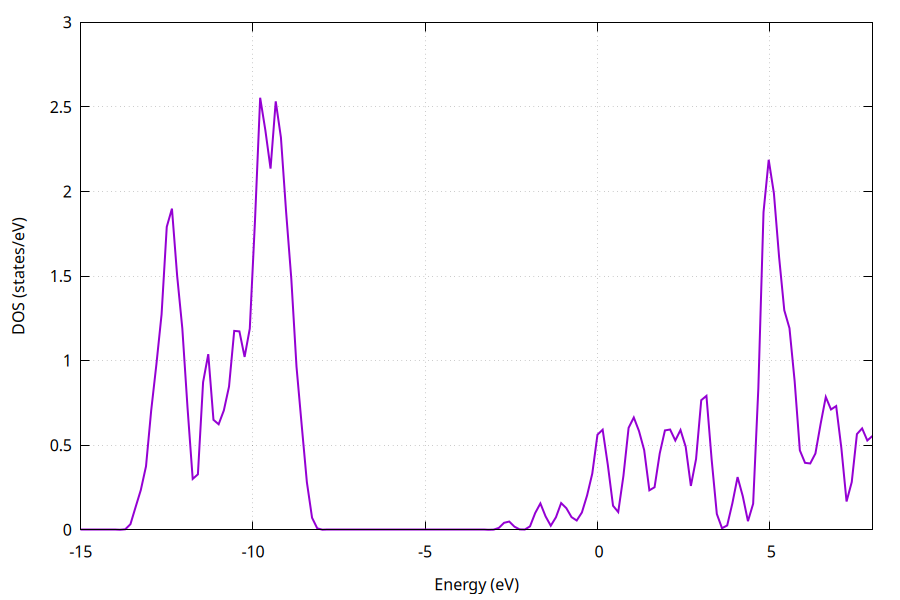

In [56]:
from IPython.display import Image
Image("MgO_DOS.png")


In [57]:
!grep -i fermi MgO.out


stepf: Fermi-Dirac step function
siesta:         Fermi =      -6.972889


## Explanation

The Fermi energy obtained from the SIESTA output is Ef = -6.973010 eV. To correctly interpret the Density of States, the energy scale is shifted using (E − Ef) so that the Fermi level lies at 0 eV. This makes it easier to identify the band gap and electronic structure of MgO.

or Only using **!Eig2DOS -k MgO.KP -f -e -15 -E 15 MgO.EIG > MgO.DOS** can automatically shift the fermi energy into 0



In [58]:
%%bash

gnuplot << 'EOF'

Ef = -6.973010   # Fermi energy from MgO.out file

set terminal pngcairo size 900,600
set output "dos_fermi.png"

set xlabel "Energy - Ef (eV)" # Shift energy so Fermi level is at 0 eV
set xrange [-15:15]
set ylabel "DOS (states/eV)"
set grid
set key off

set arrow from 0, graph 0 to 0, graph 1 nohead dt 2 lw 2   # Vertical line at Fermi level

plot "MgO.DOS" using ($1 - Ef):4 with lines lw 2   # Plot total DOS (column 4) with energy shift

EOF


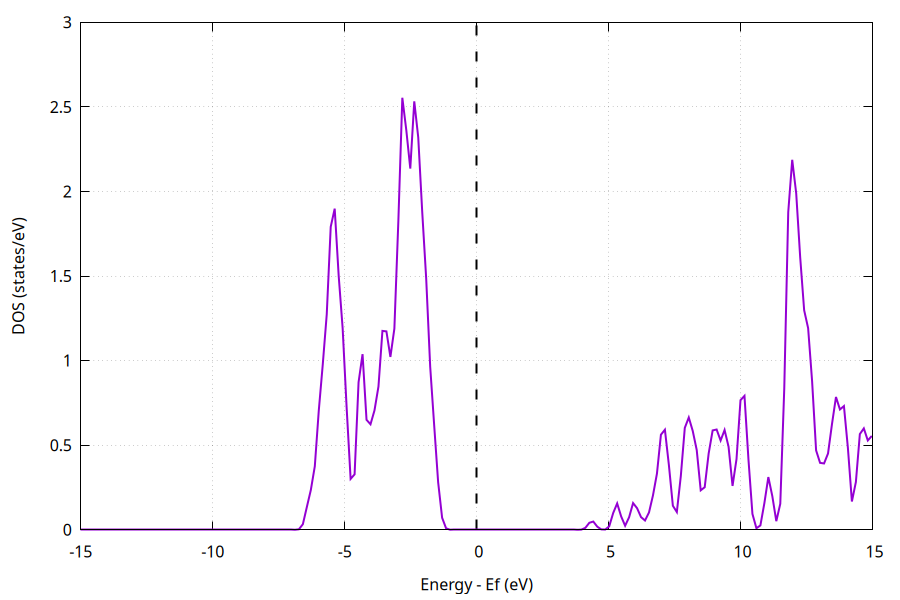

In [59]:
from IPython.display import Image
Image("dos_fermi.png")


## **Interpretation of DOS Plot**

The Density of States plot shows that the DOS at the Fermi level (0 eV) is zero, confirming that MgO is an insulator. There is a clear band gap between the valence band and conduction band, where no electronic states are present. This band gap indicates that electrons require additional energy to move into the conduction band, preventing electrical conduction under normal conditions.


## **BandStructrue of MgO**

In [60]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/first-crystals/MgO/EX1


In [87]:
!gnubands -G -o bands -F -b 1 -B 7 MgO.bands 

#This command uses the gnubands utility to convert the MgO.bands file generated by SIESTA into plottable files.
#-G creates a gnuplot script file (bands.gplot)
#-o bands sets the output file prefix
#-F shifts the energy scale so that the Fermi level is at 0 eV
#-b 1 -B 5 selects bands from band index 1 to 7

In [88]:
!gnuplot -persist -e "set grid" bands.gplot

In [89]:
%%bash

gnubands < MgO.bands > bands.dat

gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "bands.png"
set xlabel "k-path"
set ylabel "Energy (eV)"
set grid
load "bands.gplot"
EOF


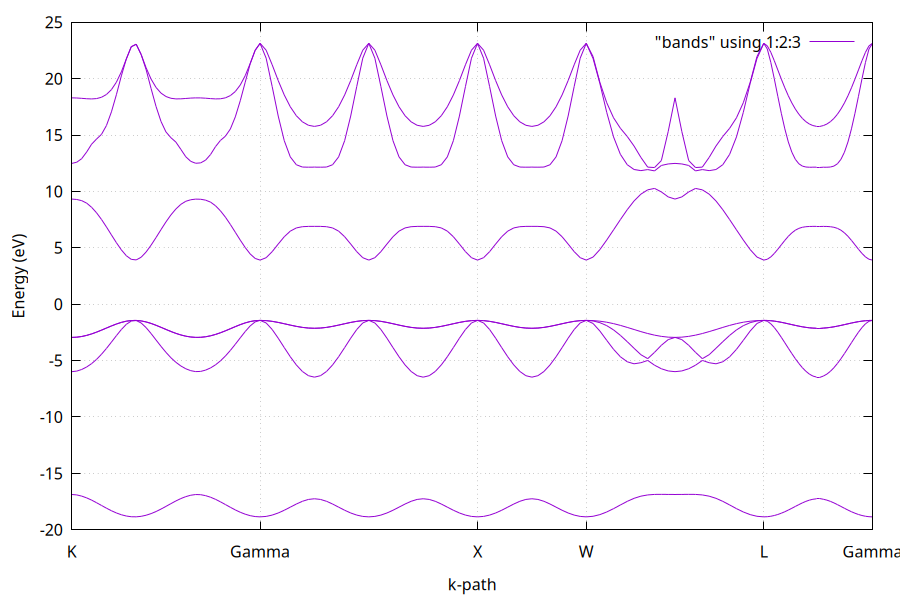

In [90]:
from IPython.display import Image, display
display(Image("bands.png"))

## Interpretation of Band Structure

The band structure plot shows the variation of electronic energy along high-symmetry directions in the Brillouin zone. A clear band gap is observed between the valence band and conduction band, and no bands cross the Fermi level. This confirms that MgO is an insulator, as electrons require additional energy to move into the conduction band.


In [108]:
%cd ..

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/first-crystals/Al


In [98]:
ls

Al/  MgO/


In [99]:
%cd Al

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/first-crystals/Al


In [100]:
ls

Al_bulk.fdf  Al.psf  bands.gplot


In [101]:
!mkdir -p EX1

In [109]:
!cp Al_bulk.fdf  Al.psf EX1/ 

In [110]:
%cd EX1

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/first-crystals/Al/EX1


In [111]:
ls

Al_bulk.fdf  Al.psf


In [112]:
!cat Al_bulk.fdf

#General system specifications
SystemName          FCC Al
SystemLabel         Al
NumberOfAtoms       1
NumberOfSpecies     1

%block ChemicalSpeciesLabel
 1  13 Al      # Species index, atomic number, species label
%endblock ChemicalSpeciesLabel
#Experimental lattice parameter 4.05 Ang
LatticeConstant 4.05 Ang

%block LatticeVectors
0.000000    0.500000   0.5000000
0.500000    0.000000   0.5000000
0.500000    0.500000   0.0000000
%endblock LatticeVectors

# Basis set definition
PAO.EnergyShift 200 meV
PAO.SplitNorm   0.15
PAO.BasisSize   SZ 

#Atomic coordinates
AtomicCoordinatesFormat  scaledcartesian

%block AtomicCoordinatesAndAtomicSpecies
  0.000000      0.000000      0.000000   1
%endblock AtomicCoordinatesAndAtomicSpecies


#Real space grid 
MeshCutoff 125.0 Ry

# K-sampling (alternative specification using kgrid_cutoff)
%block kgrid_Monkhorst_Pack
     4  0  0  0.5
     0  4  0  0.5
     0  0  4  0.5
%endblock kgrid_Monkhorst_Pack

# Convergence of SCF 
MaxSCFIterations 50
DM.M

In [113]:
!siesta < Al_bulk.fdf > Al.out

Job completed


In [114]:
ls

0_NORMAL_EXIT      Al.HSX          BASIS_HARRIS_ENTHALPY
Al.alloc           Al.ion          CLOCK
Al.bands           Al.ion.nc       fdf.20260218T122449.936.log
Al.BASIS_ENTHALPY  Al.ion.xml      FORCE_STRESS
Al.bib             Al.KP           INPUT_TMP.46116
Al.BONDS           Al.ORB_INDX     MESSAGES
Al.BONDS_FINAL     Al.out          NON_TRIMMED_KP_LIST
Al_bulk.fdf        Al.psf          OUTVARS.yml
Al.DM              Al.STRUCT_OUT   PARALLEL_DIST
Al.EIG             Al.XV
Al.FA              BASIS_ENTHALPY


In [162]:
%cd EX1

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/first-crystals/Al/EX1


In [163]:
!Eig2DOS -k Al.KP -f -e -15 -E 15 Al.EIG > Al.DOS

In [164]:
!gnuplot -persist -e 'set grid; plot "Al.DOS" using 1:4 with lines'

In [165]:
!grep -i fermi Al.out

stepf: Fermi-Dirac step function
siesta:         Fermi =      -3.688229


In [166]:
!tail Al.DOS


     13.643216      0.021869      0.021869      0.043738
     13.793970      0.000938      0.000938      0.001876
     13.944724      0.000013      0.000013      0.000026
     14.095477      0.000000      0.000000      0.000000
     14.246231      0.000000      0.000000      0.000000
     14.396985      0.000000      0.000000      0.000000
     14.547739      0.000000      0.000000      0.000000
     14.698492      0.000000      0.000000      0.000000
     14.849246      0.000000      0.000000      0.000000
     15.000000      0.000000      0.000000      0.000000


In [167]:
%%bash

gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "Al_DOS.png"

set xlabel "Energy (eV)"
set xrange [-15:8]
set ylabel "DOS (states/eV)"
set grid
set key off

plot "Al.DOS" using 1:4 with lines lw 2
EOF


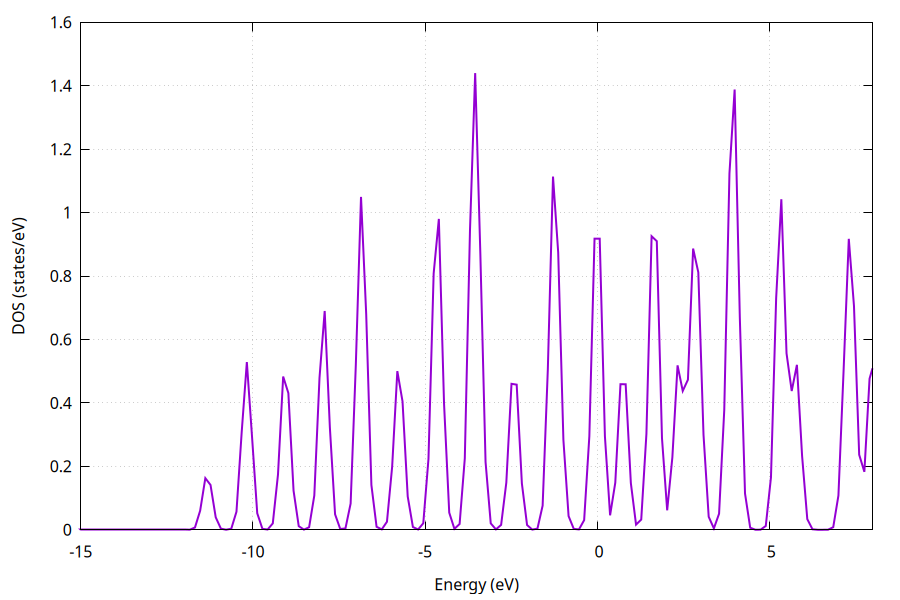

In [168]:
from IPython.display import Image, display
display(Image("Al_DOS.png"))

## **Interpretation of Aluminium DOS**

The Density of States plot for Aluminium shows a finite DOS at the Fermi level (0 eV), indicating that electronic states are available for conduction. There is no band gap, and the DOS is continuous across the Fermi energy. This confirms that Aluminium is a metal with high electrical conductivity.


In [138]:
!gnubands -G -o bands -F -b 1 -B 4 Al.bands 

In [139]:
!gnuplot -persist -e "set grid" bands.gplot

In [140]:
%%bash

gnubands < Al.bands > bands.dat

gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "bands.png"
set xlabel "k-path"
set ylabel "Energy (eV)"
set grid
load "bands.gplot"
EOF


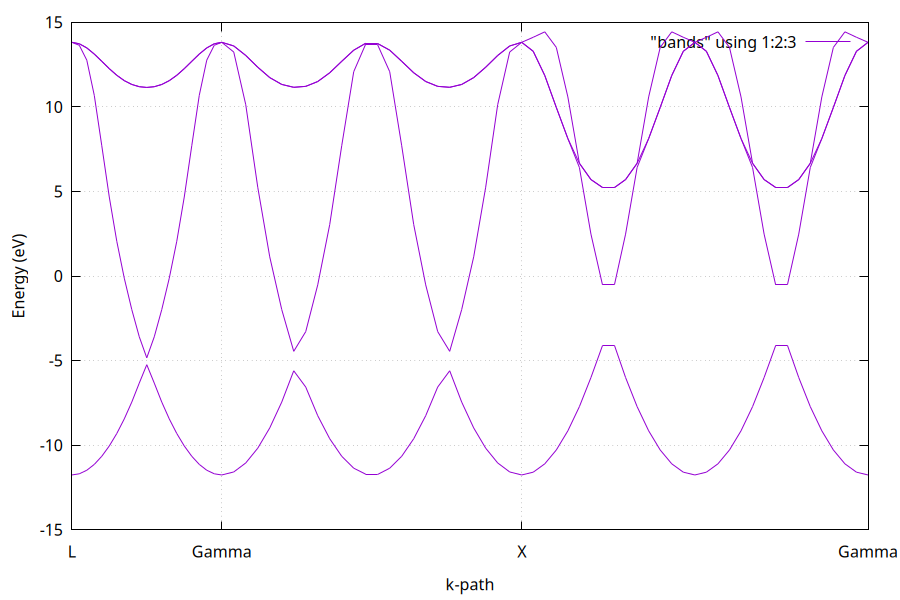

In [141]:
from IPython.display import Image, display
display(Image("bands.png"))

## Energy Variation with k-Points

In a crystal, electrons behave as waves and are described by their wave vector (k-point) in reciprocal space. The band structure plot shows how the electron energy changes with different k-points along high-symmetry directions in the Brillouin zone. This relationship, E(k), forms energy bands due to the periodic potential of the crystal lattice. The variation of energy with k-points determines the electronic properties of the material. In Aluminium, several bands cross the Fermi level, confirming its metallic nature and allowing electrons to move freely through the crystal.
L, Γ, and X are high-symmetry points in the Brillouin zone. The path L → Γ → X → Γ represents different directions in reciprocal space. The band structure shows how electron energy changes along this path, which determines the electronic properties of the material.


In [169]:
%cd ..

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/first-crystals/Al


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# **Icreasing k-point mesh**

In [170]:
%cd MORE_KP

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/first-crystals/Al/MORE_KP


In [144]:
!mkdir MORE_KP


In [146]:
!cp Al_bulk.fdf Al.psf MORE_KP
%cd MORE_KP

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/first-crystals/Al/MORE_KP


In [147]:
ls

Al_bulk.fdf  Al.psf


In [148]:
!siesta < Al_bulk.fdf > Al.out

Job completed


In [150]:
!grep -i fermi Al.out

stepf: Fermi-Dirac step function
siesta:         Fermi =      -3.755692


In [151]:
!Eig2DOS -k Al.KP Al.EIG > Al.dos

In [156]:
!gnuplot -persist -e 'set grid; plot "Al.dos" using 1:4 with lines'


In [179]:
%%bash

gnuplot << EOF
set terminal pngcairo size 900,600
set output "Al_DOS.png"
set xlabel "Energy (eV)"
set ylabel "DOS (states/eV)"
set grid
plot "Al.dos" using 1:4 with lines lw 2  
EOF


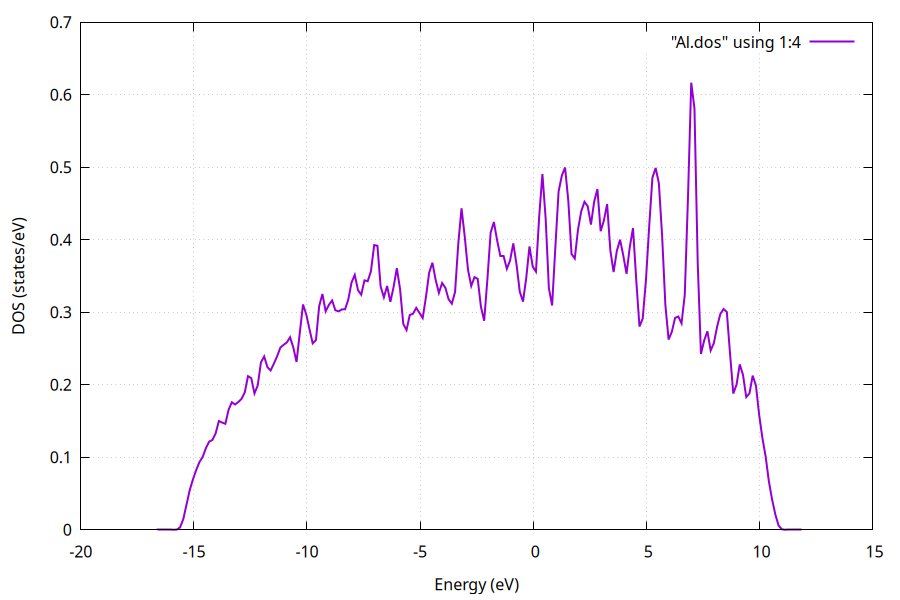

In [180]:
from IPython.display import Image, display
display(Image("Al_DOS.png"))

In [173]:
%%bash 
gnubands -G -o bands -F -b 1 -B 4 Al.bands 
gnuplot -persist -e "set grid" bands.gplot

In [174]:
%%bash

gnubands < Al.bands > bands.dat

gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "bands.png"
set xlabel "k-path"
set ylabel "Energy (eV)"
set grid
load "bands.gplot"
EOF


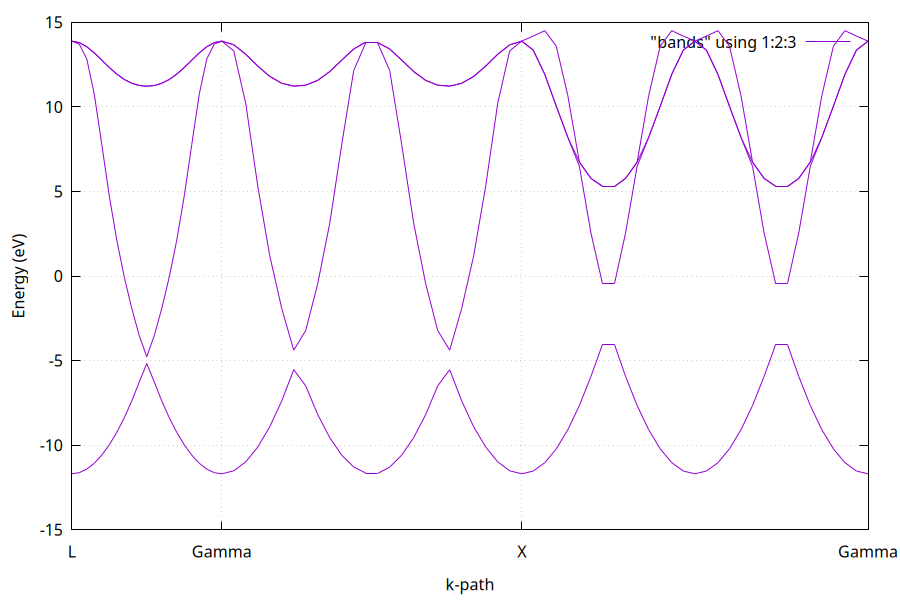

In [175]:
from IPython.display import Image, display
display (Image("bands.png"))

As a following part tutorial **First Crystals** , now we checked the DOS of bulk Aluminium by increase the sampling grid from 4X4X4 to 14x14x14. **Why doing so ?** Because electronic properties of any materials is confined only in the first brillioun zone(outer the brillioun zone is just the periodicity of first brillioun zone)and get by **integration** over the reciprocal space.Roughly sample over the brillioun zone led to missing information and lack of data collected, then it can't give accurate result. This is what exactly happen in the previous exercise when the k-point mesh was $4x4x4$ and lot of noise in the DOS plot due to insufficient sampling. 

Increasing K-point grid upto $14X14X14$, the DOS becoming smooth and more continous.This is because of **dense k-point mesh**(information loss is minimize) gives more accurate integration over the **reciprocal space.**

## **Density of State**

From the DOS plot, it clearly show that there is some electronics state at the fermi level i.e DOS at fermi level is non zero. Due to this states, electron can easily excited and move to the conduction bands. That why Al is mettalic in nature.

In [182]:
%cd ..

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/first-crystals
